# Warp Regression: An Introduction

Many series have a recognisable **shape** whose **timing** drifts — a business cycle that is usually four years but sometimes six, a boom–bust pattern that peaks early one decade and late the next.

Fixed-phase tools (ARIMA, seasonal decomposition) leave nowhere for that wander. Flexible smoothers fit the mistiming as unstructured noise and lose the "same shape, early or late" story.

**Warp regression** sits in between: warp a known-shape cycle through an observation model

$$\hat{y}_i = f\big(\mathrm{warp}(c, p)_i\big)$$

- $f$ maps the warped cycle onto the target (linear, MLP, …).
- $p$ is a low-dimensional path of fractional indices into $c$. Soft-warp interpolates, so gradients flow through $p$.

## Dual loss

Training mixes two likelihoods with weight $\lambda$ (`fit_lambda`):

| Term | Role |
|------|------|
| **error** | Gaussian NLL of residuals $y - \hat{y}$ (scale $\sigma_y$) |
| **terror** | Random-walk likelihood on offsets $p(i)-i$ (scale $\sigma_t$) |

$$\mathrm{loss} = \lambda \cdot \mathrm{error} - (1-\lambda) \cdot \mathrm{terror}$$

Because the path has a likelihood, you can **sample** future paths for forecast bands: a **terror** band (timing only) and a **combined** band (timing + observation noise).

This notebook grades the method on synthetic data with a known true warp; Lynx and Bitcoin follow on real series.


In [1]:
%matplotlib inline

import sys
from pathlib import Path
for _p in (Path.cwd().resolve().parents[1] / "src", Path.cwd().resolve().parent):
    s = str(_p)
    if _p.is_dir() and s not in sys.path:
        sys.path.insert(0, s)

import matplotlib.pyplot as plt
import numpy as np
import torch

from utils import (
    build_synthetic_dataset,
    cumsum_path_to_stored_path,
    evaluate_model,
    plot_fit_with_residual,
    plot_forecast_bands,
    plot_realisation_spaghetti,
    plot_warp_offset,
    roll_forward_synthetic,
    split_holdout,
)
from warp_regression import (
    DEFAULT_PATH_ANCHOR,
    eval_sine_driver,
    WarpModel,
    analyze_cycle_lengths,
    build_forecast_bands,
    interval_coverage,
    per_index_rw_sigma,
    plot_cycle_length_distribution,
    predict_forecast_realisations_torch,
    predict_realisations_torch,
    prefit,
    soft_warp_numpy,
    stored_path_offset_numpy,
)

plt.rcParams.update({"figure.figsize": (10, 3.5), "axes.grid": True, "grid.alpha": 0.3})


## Step 1: synthetic data with a known warp

Generate a sine, push it through a hidden random-walk warp, add noise. Hold out the last 100 points so we can check forecasts the same way as on real data.


/Users/ap/Desktop/warp/warp_regression/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


n=300  sr=10  scale=15.0  noise_std=0.2
corr(x, y)=0.292  (low ⇒ obvious timing mismatch; warp should restore alignment)
Train indices 0-180 (n=181)  |  Test indices 181-299 (n=119)


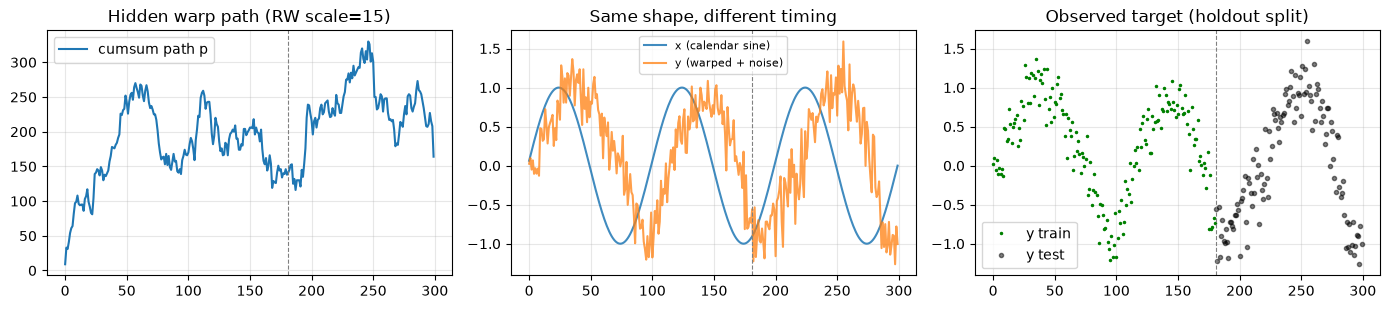

In [2]:
data = build_synthetic_dataset()  # default scale=15: stronger hidden RW warp
print(f"n={data['n']}  sr={data['sr']}  scale={data['scale']}  noise_std={data['noise_std']}")
print(
    f"corr(x, y)={np.corrcoef(data['x'], data['y'])[0, 1]:.3f}  "
    f"(low ⇒ obvious timing mismatch; warp should restore alignment)"
)

split = split_holdout(data["n"], n_train=181)
train_idx, test_idx = split["train_idx"], split["test_idx"]
n_train, n_test = split["n_train"], split["n_test"]
print(f"Train indices 0-{n_train - 1} (n={n_train})  |  Test indices {n_train}-{data['n'] - 1} (n={n_test})")

y_train = torch.tensor(data["y"][train_idx], dtype=torch.float32)
sr = data["sr"]

fig, axes = plt.subplots(1, 3, figsize=(14, 3.2))
axes[0].plot(data["p_true"], label="cumsum path p")
axes[0].axvline(n_train - 0.5, color="gray", ls="--", lw=0.8)
axes[0].set_title(f"Hidden warp path (RW scale={data['scale']:g})")
axes[0].legend()
axes[1].plot(data["x"], label="x (calendar sine)", alpha=0.85)
axes[1].plot(data["y"], label="y (warped + noise)", alpha=0.75)
axes[1].axvline(n_train - 0.5, color="gray", ls="--", lw=0.8)
axes[1].set_title("Same shape, different timing")
axes[1].legend(fontsize=8)
axes[2].plot(train_idx, data["y"][train_idx], "g.", ms=3, label="y train")
axes[2].plot(test_idx, data["y"][test_idx], "ko", ms=3, alpha=0.5, label="y test")
axes[2].axvline(n_train - 0.5, color="gray", ls="--", lw=0.8)
axes[2].set_title("Observed target (holdout split)")
axes[2].legend()
fig.tight_layout()
plt.show()


## Step 2: prefit the cycle on calendar time

Before learning a warp, align a sine to the training series on the calendar (`prefit`). That sine $z$ is what gets warped next:

$$\hat{y} = A \cdot \mathrm{warp}(z, p) + C$$


In [3]:
t_tr = (train_idx + 1).astype(np.float64) / 100.0
t_full = (np.arange(data["n"]) + 1).astype(np.float64) / 100.0
prefit_res = prefit(y_train.numpy(), t_tr, n_sines=1, t_full=t_full)
sine_fit = prefit_res.sine_fit
z_prefit = torch.tensor(prefit_res.covariates["z"], dtype=torch.float32)
print(
    f"prefit: omega={sine_fit['omega']:.3f}  phase={sine_fit['phase']:.3f}  "
    f"corr={sine_fit['presize_corr']:.3f}"
)


prefit: omega=1.000  phase=5.236  corr=0.882


The image below shows the target, and the input sine wave before and after prefit alignment. You can see the timing mismatch that the warp will need to fix.


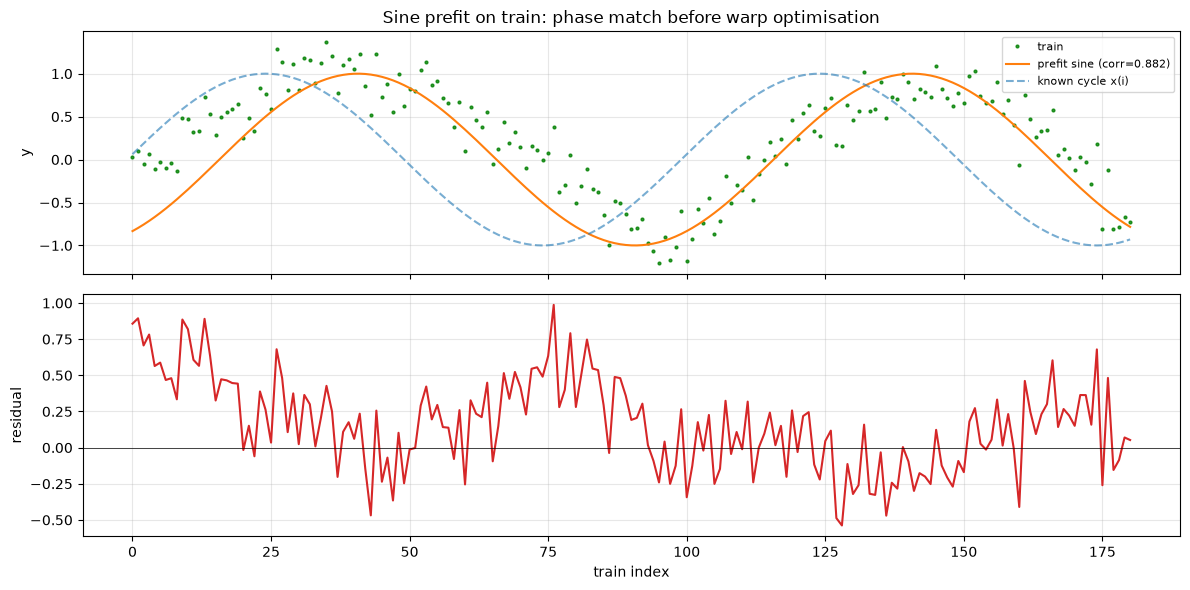

In [4]:
z_pre = sine_fit["z"]
y_np = y_train.numpy()
x_raw = data["x"][:n_train]

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
plot_fit_with_residual(
    axes, train_idx, y_np, z_pre,
    extra_lines=[(train_idx, x_raw, {"color": "C0", "ls": "--", "alpha": 0.6, "label": "known cycle x(i)"})],
    fit_label=f"prefit sine (corr={sine_fit['presize_corr']:.3f})",
    xlabel="train index",
    title="Sine prefit on train: phase match before warp optimisation",
)
plt.tight_layout()
plt.show()


## Step 3: joint training

Learn path knots $B$, amplitude $A$, bias $C$, and scales $\sigma_t$, $\sigma_y$ together under the dual loss. The path is **start-pinned** ($p[0]=0$) so the train end can move. The covariate sine is evaluated on an **extended** calendar so expansion can read future cycle values.


In [5]:
from warp_regression.covariates.sine import eval_sine_driver

n_ext = n_train + n_test
t_ext = (np.arange(n_ext) + 1).astype(np.float64) / 100.0
x_ext = eval_sine_driver(
    t_ext, sine_fit["omega"], sine_fit["phase"],
    time_scale=sine_fit.get("time_scale", 1.0),
    t_shift=sine_fit.get("t_shift", 0.0),
)
x_train = torch.tensor(x_ext, dtype=torch.float32)
y_np = y_train.numpy()

model = WarpModel.from_yaml("synthetic.yaml", n=n_train)
model.fit(
    y_np, covariates={"x": x_ext}, sine_fit=sine_fit,
    epochs=5000, lr=0.03, seed=0, fit_lambda=0.5,
)

with torch.no_grad():
    sigma_t = float(model.sigma_t)
    p_fit = model.primary_path.path().numpy()
    y_hat_t, _ = model.predict_torch(
        {"x": x_train}, {}, p=torch.tensor(p_fit), sine_fit=sine_fit
    )
    y_hat_tr = y_hat_t.numpy()
report = evaluate_model(model, y_np, x=x_ext, use_discrete_warp=True)
print(f"σ_t={sigma_t:.4f}  terminal offset={p_fit[-1]-(n_train-1):.3f}")
print(report)


σ_t=0.1630  terminal offset=2.081
EvalReport(mse=0.061268618289255346, rmse=0.24752498518181018, corr=0.9140969681663751, obj_err=4.10775899887085, obj_time=0.4015570282936096, err_nll=-4.10775899887085, time_ll=-0.4015570282936096, ll_distance=None, discrete_mse=0.061268617065375515)


## Step 4: did the warp recover?

On synthetic data we know the true path. Compare the fitted curve, $p$, and offsets $p(i)-i$ to ground truth.


Path anchor: start-pinned (p[0]=0.00, terminal offset=2.08)
  learned p vs ground-truth stored path corr = 0.992
  prefit sine corr (step 2) = 0.882


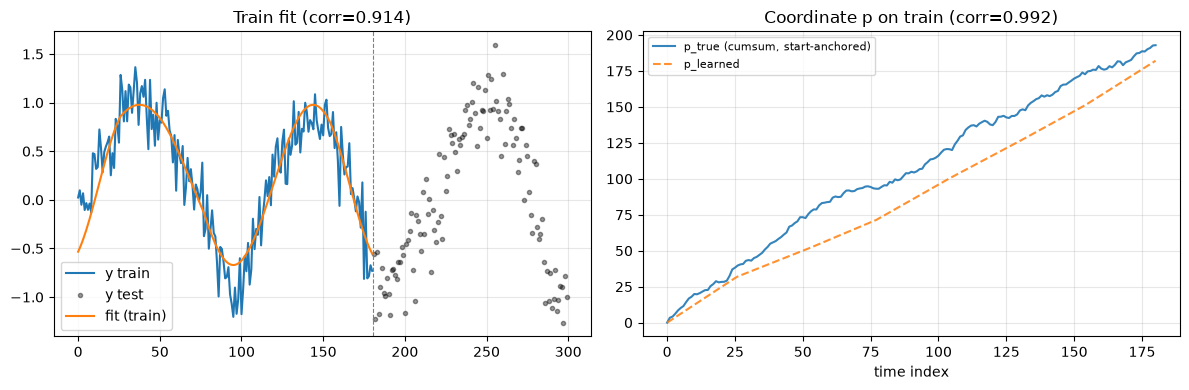

In [6]:
with torch.no_grad():
    p_fit = model.primary_path.path().numpy()
    y_fit_t, _ = model.predict_torch(
        {"x": x_train}, {}, p=torch.tensor(p_fit), sine_fit=sine_fit
    )
    y_fit = y_fit_t.numpy()

p_true_stored = cumsum_path_to_stored_path(
    data["p_true"], n_train, sr, path_anchor=DEFAULT_PATH_ANCHOR
)

off_fit = stored_path_offset_numpy(p_fit)
print(f"Path anchor: start-pinned (p[0]={p_fit[0]:.2f}, terminal offset={off_fit[-1]:.2f})")
print(f"  learned p vs ground-truth stored path corr = {np.corrcoef(p_true_stored, p_fit)[0,1]:.3f}")
print(f"  prefit sine corr (step 2) = {sine_fit['presize_corr']:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(train_idx, y_train.numpy(), label="y train")
ax[0].plot(test_idx, data["y"][test_idx], "ko", ms=3, alpha=0.4, label="y test")
ax[0].plot(y_fit, label="fit (train)")
ax[0].axvline(n_train - 0.5, color="gray", ls="--", lw=0.8)
ax[0].legend()
ax[0].set_title(f"Train fit (corr={report.corr:.3f})")

ax[1].plot(p_true_stored, label="p_true (cumsum, start-anchored)", alpha=0.9)
ax[1].plot(p_fit, linestyle="--", label="p_learned", alpha=0.85)
ax[1].legend(fontsize=8)
ax[1].set_title(f"Coordinate p on train (corr={np.corrcoef(p_true_stored, p_fit)[0,1]:.3f})")
ax[1].set_xlabel("time index")
plt.tight_layout()
plt.show()


### What else could have happened?

The orange line above is one MAP path. Given that fit and $\sigma_t$, other warps are still plausible.

The spaghetti samples those alternatives on the **train** window: *according to our warp fit, what else could have happened?* Start-pinned, so almost no uncertainty at $t=0$, growing toward the end.


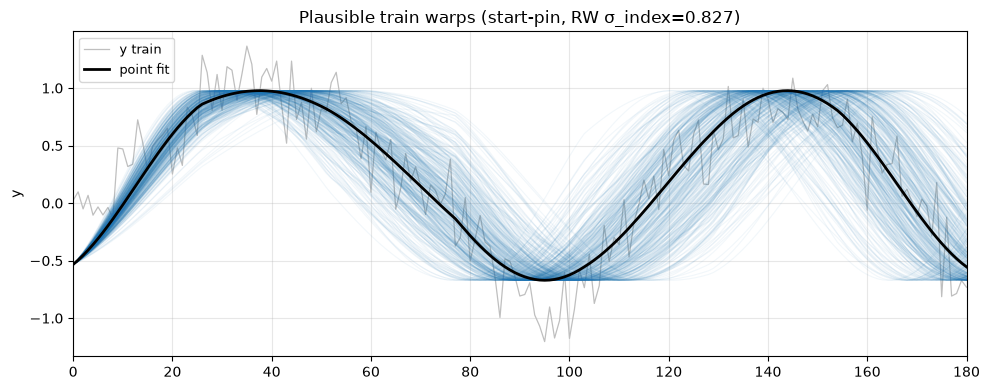

paths shape (400, 181)  std[0]=0.0000  std[180]=0.3192  (expect std[0]≪std[end])


In [7]:
h = n_train
n_draws = 400
paths = predict_realisations_torch(model, x=x_ext, n_draws=n_draws, horizon=h)

with torch.no_grad():
    y_fit_t, _ = model.predict_torch({"x": x_train}, {}, sine_fit=sine_fit)
    y_fit = y_fit_t.numpy()

sigma_t = float(model.sigma_t.detach())
sigma_step = per_index_rw_sigma(sigma_t, n_train, model.primary_path.n_knots)

fig, ax = plt.subplots(figsize=(10, 4))
plot_realisation_spaghetti(
    ax, np.arange(h), paths, np.arange(h), y_fit,
    x_obs=train_idx, y_obs=y_np, obs_label="y train",
    point_label="point fit", path_alpha=0.06,
    title=f"Plausible train warps (start-pin, RW σ_index={sigma_step:.3f})",
)
ax.set_xlim(0, h - 1)
fig.tight_layout()
plt.show()

print(
    f"paths shape {paths.shape}  std[0]={paths[:, 0].std():.4f}  "
    f"std[{h-1}]={paths[:, -1].std():.4f}  (expect std[0]≪std[end])"
)


## Step 5: how long will the next cycle be?

The terror loss gives a timing scale $\sigma_t$ — a time standard deviation on the warp. With that scale we can sample plausible future warp paths and read the expected length of future cycles from peak-to-peak spacing on each draw.

The histogram is those sampled lengths. Compare the calculated (sampled) cycle length to the **actual** next cycle on the known synthetic warp, and to the nominal unwarped period.


Nominal cycle ≈ 100.0 steps  |  sample median = 95.0 steps  |  actual = 102.0 steps  |  σ_t = 0.163


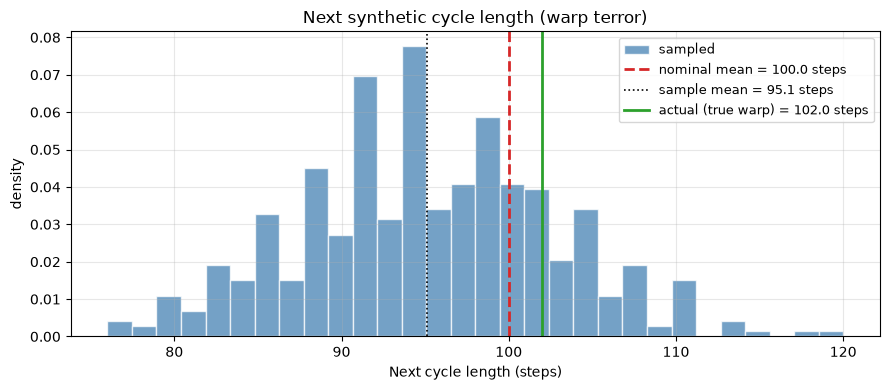

In [8]:
cyc = analyze_cycle_lengths(
    model=model,
    sine_fit=sine_fit,
    n_calendar=n_train,
    unit="steps",
    n_paths=500,
    seed=7,
)

# Actual next cycle on the known true warp (same soft-warp + peak spacing as the samples).
p_true_full = cumsum_path_to_stored_path(
    data["p_true"], data["n"], sr, path_anchor=DEFAULT_PATH_ANCHOR
)
t_full_idx = float(sine_fit["t0"]) + float(sine_fit["dt"]) * np.arange(len(p_true_full))
z_true = soft_warp_numpy(
    eval_sine_driver(t_full_idx, float(sine_fit["omega"]), float(sine_fit["phase"])),
    p_true_full,
)
from scipy.signal import find_peaks

_min_sep = max(1, int(0.35 * cyc.mean_cycle_length))
_peaks, _ = find_peaks(z_true, height=0.0, distance=_min_sep)
_anchor = n_train - 1
_last = int(_peaks[_peaks <= _anchor][-1])
_next = int(_peaks[_peaks > max(_anchor, _last + _min_sep - 1)][0])
actual_len = float(_next - _last)

fig, ax = plt.subplots(figsize=(9, 4))
plot_cycle_length_distribution(cyc, ax=ax, title="Next synthetic cycle length (warp terror)")
ax.axvline(
    actual_len,
    color="C2",
    lw=2,
    label=f"actual (true warp) = {actual_len:.1f} {cyc.unit}",
)
ax.legend(fontsize=9)
print(
    f"Nominal cycle ≈ {cyc.mean_cycle_length:.1f} steps  |  "
    f"sample median = {np.median(cyc.lengths):.1f} steps  |  "
    f"actual = {actual_len:.1f} steps  |  σ_t = {cyc.sigma_t:.3f}"
)
fig.tight_layout()
plt.show()


## Step 6: forecast the holdout

Continue the fitted path with a terror-scale random walk. Percentile bands give timing uncertainty (terror) and total predictive uncertainty (terror + $\sigma_y$).


σ_t=0.163  σ_y=0.248  CI 95%: combined coverage=82.4%  terror=50.4%


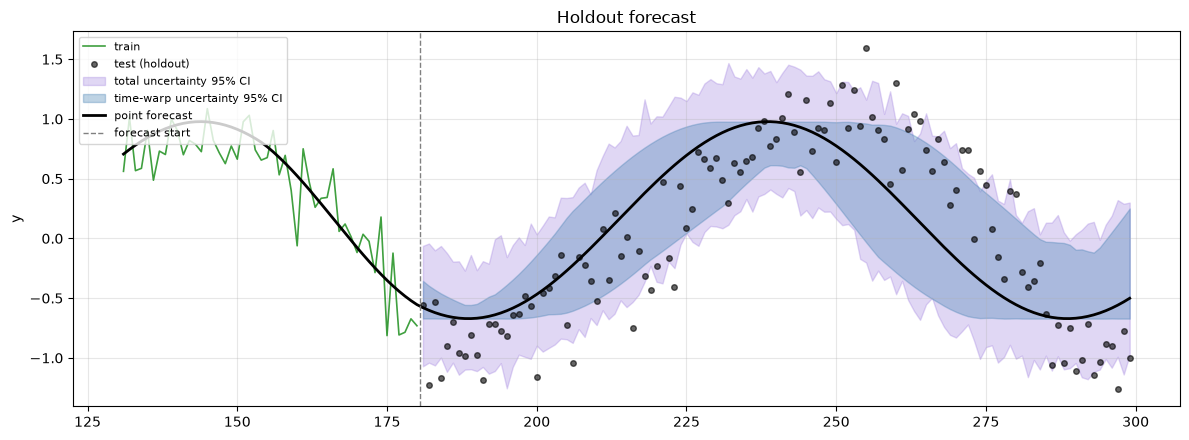

In [9]:
n_future, n_context, n_draws, ci = n_test, 50, 100, 0.95

fc = predict_forecast_realisations_torch(
    model, n_future=n_future, n_draws=n_draws, n_paths_ci=n_draws,
    seed=1, noise_seed=7, sine_fit=sine_fit, ci=ci,
)
y_point, sigma_y, sigma_t = fc["y_point"], fc["sigma_y"], fc["sigma_t"]
y_test = data["y"][test_idx]
bands = build_forecast_bands(fc["preds"][:n_draws], y_point, sigma_y, ci=ci, noise_seed=7)

cov_combined = interval_coverage(y_test, bands["c_q_lo"][test_idx], bands["c_q_hi"][test_idx])
cov_terror = interval_coverage(y_test, bands["t_q_lo"][test_idx], bands["t_q_hi"][test_idx])
print(
    f"σ_t={sigma_t:.3f}  σ_y={sigma_y:.3f}  "
    f"CI {ci:.0%}: combined coverage={cov_combined:.1%}  terror={cov_terror:.1%}"
)

plot_start = max(0, n_train - n_context)
bands_fc = {k: bands[k][n_train:] for k in ("t_q_lo", "t_q_hi", "c_q_lo", "c_q_hi")}
bands_fc["ci"] = ci
fig, ax = plt.subplots(figsize=(12, 4.5))
plot_forecast_bands(
    ax,
    np.arange(plot_start, n_train), data["y"][plot_start:n_train],
    np.arange(n_train, n_train + n_test), bands_fc,
    x_test=test_idx, y_test=y_test,
    point_lines=[(np.arange(plot_start, n_train + n_test), y_point[plot_start:],
                  {"color": "black", "lw": 2, "label": "point forecast"})],
    forecast_start_x=n_train - 0.5,
    title="Holdout forecast",
)
plt.tight_layout(); plt.show()


## Step 7: roll-forward coverage

Expanding-window check: at several origins, refit on the past, forecast a fixed horizon, and compare band coverage to the nominal level.


In [10]:
rows = roll_forward_synthetic(data['y'], horizon=100, step=20, t0_first=100, epochs=2000)


roll-forward: origins=100…200 step=20  horizon=100  ci=95%  n_windows=6
   t0     total      warp   cycle_med      σ_t
------------------------------------------------


  100     19.0%     17.0%       206.0    0.136


  120     91.0%     53.0%       106.0    0.154


  140     87.0%     50.0%       113.0    0.159


  160     91.0%     62.0%        97.0    0.161


  180     87.0%     55.0%        95.0    0.163


  200     64.0%     35.0%        89.0    0.162
------------------------------------------------
OVERALL  total 73.2%  warp 45.3%  (nominal 95%)


## Wrapping up

1. Prefit a calendar sine, then warp it under a dual (error + terror) likelihood.
2. On synthetic data the path recovers; $\sigma_t$ yields plausible path draws and a next-cycle length distribution to compare against the true warp.
3. Holdout bands and roll-forward coverage check that the uncertainty story is not one-window luck.

Next: [`2_Adding_complexity_Lynx_Forecast.ipynb`](2_Adding_complexity_Lynx_Forecast.ipynb) — two cycles, shared warp, nonlinear readout.
